# TwiBot-20 transfer-OUT: NM model trained on TwiBot-20 -> every other graph/task

Experiment (a): a neighbor-matching model pretrained on the **TwiBot-20** retweet
graph (`nm_twibot20`, 120k steps) evaluated on every other graph. Two eval tasks:
**neighbor matching** (30-way, 3-shot) and **classification** (few-shot, where the
target graph has labels). `twibot20` itself is the in-domain reference.
Data: `twibot20_transfer_out_metrics.csv` (downloaded from Tucker eval logs).

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

DATA = Path("twibot20_transfer_out_metrics.csv")
FIG_DIR = Path("figures"); FIG_DIR.mkdir(exist_ok=True)
df = pd.read_csv(DATA)

SELF = "#d1741f"    # in-domain (twibot20)
OTHER = "#2f6f9f"   # transfer target
def colors_for(sub): return [SELF if s else OTHER for s in sub["is_self"]]
df.head(20)

,target,task,is_self,accuracy,f1,roc_auc
0,election2020,classification,False,0.943000,0.943284,0.970828
1,covid_political,classification,False,0.706667,0.707203,0.777669
2,twibot20,classification,True,0.534333,0.578200,0.551237
3,ukr_rus_suspended,classification,False,0.512000,0.536122,0.517080
4,twibot20,nm,True,0.483906,0.483896,0.950737
5,merged_covid_midterm,nm,False,0.501928,0.501920,0.940775
6,covid19_twitter,nm,False,0.499828,0.499820,0.940427
7,merged_ukr_rus_covid,nm,False,0.466294,0.466245,0.924319
8,ukr_rus_twitter,nm,False,0.339633,0.339640,0.852293
9,midterm,nm,False,0.269800,0.269864,0.847463


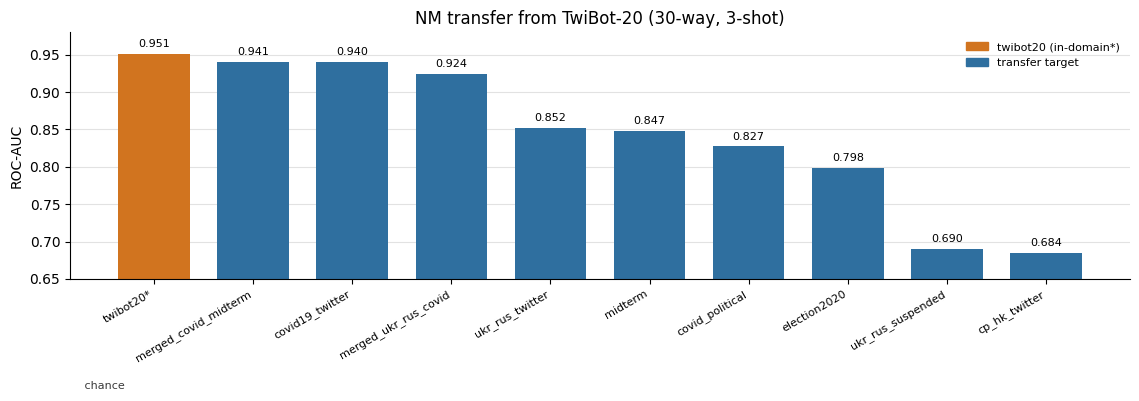

In [2]:
def style_axis(ax):
    ax.spines[["top","right"]].set_visible(False)
    ax.grid(axis="y", color="#d7d7d7", linewidth=0.8, alpha=0.7)
    ax.set_axisbelow(True)

def annotate(ax, bars, fmt="{:.3f}"):
    ymin,ymax=ax.get_ylim(); pad=(ymax-ymin)*0.02
    for b in bars:
        v=b.get_height()
        ax.text(b.get_x()+b.get_width()/2, v+pad, fmt.format(v), ha="center", va="bottom", fontsize=8)

def bars_for(task, metric, title, ylabel, chance=None, ylim=None, fname=None):
    sub = df[df.task.eq(task)].sort_values(metric, ascending=False).reset_index(drop=True)
    fig, ax = plt.subplots(figsize=(max(7, 1.15*len(sub)), 4.6))
    bars = ax.bar(range(len(sub)), sub[metric].values, color=colors_for(sub), width=0.72)
    ax.set_xticks(range(len(sub)))
    ax.set_xticklabels([("%s*" % t) if s else t for t,s in zip(sub.target, sub.is_self)],
                       rotation=30, ha="right", fontsize=8)
    if ylim: ax.set_ylim(*ylim)
    if chance is not None:
        ax.axhline(chance, color="#3a3a3a", ls="--", lw=1.1)
        ax.text(0.01, chance, " chance", transform=ax.get_yaxis_transform(),
                va="bottom", fontsize=8, color="#3a3a3a")
    ax.set_title(title); ax.set_ylabel(ylabel); style_axis(ax); annotate(ax, bars)
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(color=SELF,label="twibot20 (in-domain*)"), Patch(color=OTHER,label="transfer target")],
              frameon=False, fontsize=8, loc="upper right")
    fig.tight_layout()
    if fname: fig.savefig(FIG_DIR/fname, dpi=200, bbox_inches="tight")
    return sub

# Neighbor matching transfer-out
bars_for("nm", "roc_auc", "NM transfer from TwiBot-20 (30-way, 3-shot)", "ROC-AUC",
         chance=0.5, ylim=(0.65, 0.98), fname="nm_transfer_out_roc_auc.png");

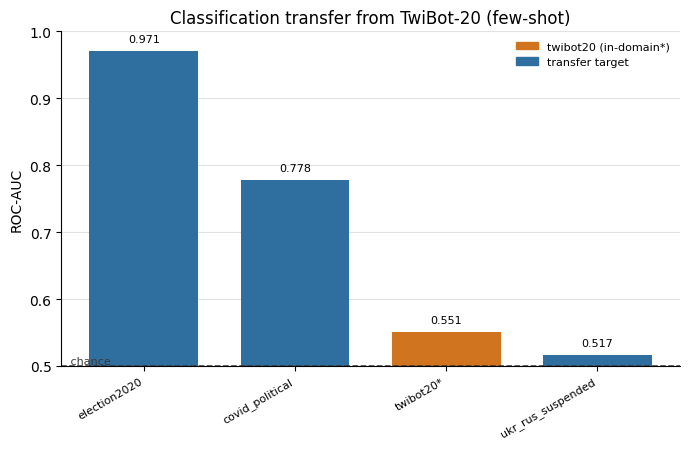

In [3]:
# Classification transfer-out (only labeled targets)
bars_for("classification", "roc_auc", "Classification transfer from TwiBot-20 (few-shot)", "ROC-AUC",
         chance=0.5, ylim=(0.5, 1.0), fname="classification_transfer_out_roc_auc.png");

## Takeaways

- **NM structure transfers broadly**: the TwiBot-20 NM model scores ROC-AUC 0.85-0.94
  on the large retweet graphs (covid, ukr_rus, merged, midterm), and 0.95 in-domain
  on TwiBot-20 itself. Weakest on the small label-graphs (ukr_rus_suspended 0.69,
  cp_hk 0.68).
- **In-domain bot classification is still only 0.55** (twibot20*): even a model
  pretrained on TwiBot-20 gives near-chance few-shot bot detection - the same ceiling
  seen in the transfer-IN direction. This is a *measurement* limit of 3-shot readout on
  NM features, not a transfer failure -> motivates the linear-probe evaluation.
- Classification transfers strongly to `election2020` (0.97) and `covid_political`
  (0.78), which are easier / more separable tasks than bot detection.